--- Fuzzification ---
speed_low   : 0.000
speed_med   : 0.500
speed_high  : 0.250
dist_near   : 0.600
dist_far    : 0.000

--- Rule firing strengths & crisp z ---
Rule 1: α=0.250, z=70.00
Rule 2: α=0.500, z=80.00
Rule 3: α=0.000, z=30.00
Rule 4: α=0.000, z=30.00
Rule 5: α=0.000, z=50.00
Rule 6: α=0.000, z=50.00

--- Defuzzification ---
Σα = 0.750
Final Brake Force Z* = 76.67 %


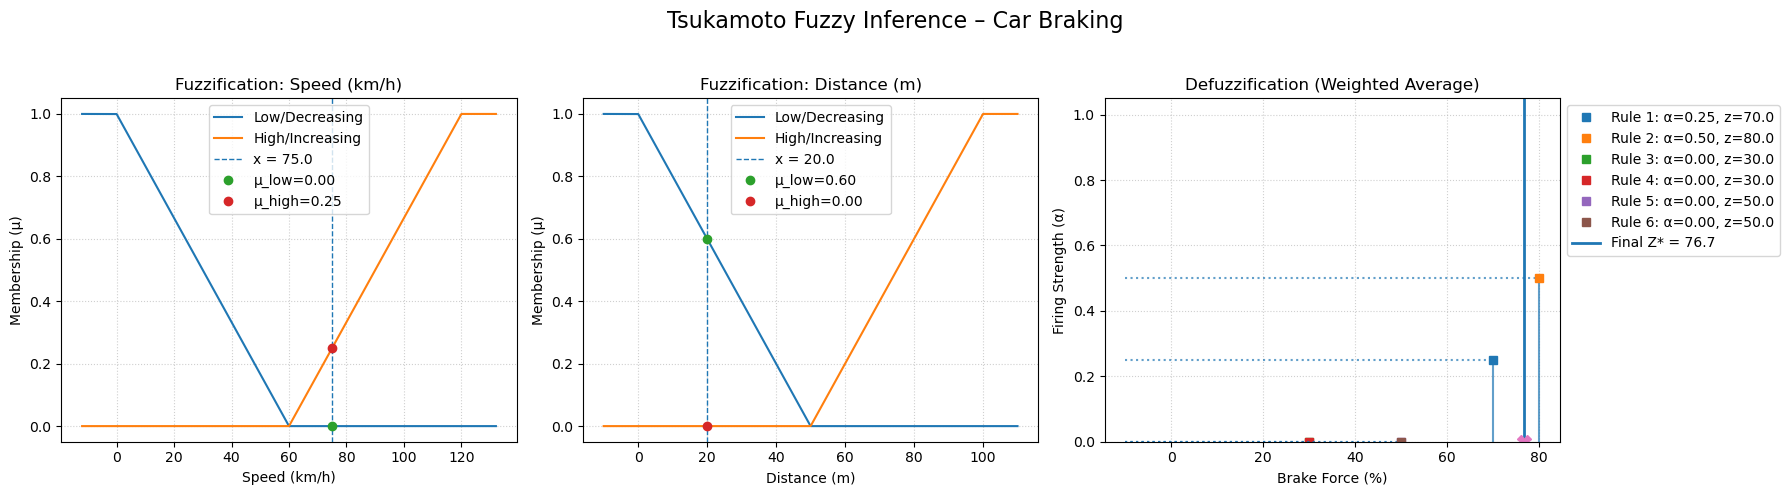

In [1]:
# -*- coding: utf-8 -*-
"""Team 3 fuzzy logic Ai

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1U1jtZPb5EIp7zBPCzgUXBDwHKB_zdYBj
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import List

# ================================
# 1) FUZZY MEMBERSHIP FUNCTIONS（模糊隶属函数）
# ================================

def membership_descending(a: float, b: float, x: float) -> float:
    """
    Degree of membership for a descending (HIGH->LOW) fuzzy set on [a, b].
    1.0 at x<=a, 0.0 at x>=b, linear in between.
    (在区间[a, b]上，一个递减型（HIGH->LOW）模糊集的隶属度分布：
    当x≤a时为1.0，当x≥b时为0.0，其间呈线性变化。)
    """
    if x <= a:
        return 1.0
    if x >= b:
        return 0.0
    #descending b is membership 0 because going down
    #           a is membership one
    return (b - x) / (b - a)


def membership_ascending(a: float, b: float, x: float) -> float:
    """
    Degree of membership for an ascending (LOW->HIGH) fuzzy set on [a, b].
    0.0 at x<=a, 1.0 at x>=b, linear in between.
    """
    if x <= a:
        return 0.0
    if x >= b:
        return 1.0
        #descending b is membership 1 because going up
    #           a is membership 0
    return (x - a) / (b - a)


# ============================================
# 2) TSUKAMOTO INVERSE MEMBERSHIP (CONSEQUENTS) Tsukamoto 后验计算隶属度
# ============================================

# for eachh cross descision we try to find for the alpha value output z
def crisp_output_descending(a: float, b: float, alpha: float) -> float:
    """
    For a descending consequent on [a,b] with µ(z) = (b - z)/(b - a),
    invert to get z from firing strength alpha.
    对于基于[a,b]的递减后验分布，其µ(z) = (b - z)/(b - a)，
    通过反验从强度α中获取z。
    """
    alpha = float(np.clip(alpha, 0.0, 1.0))
    # z = b - alpha * (b - a)
    return b - alpha * (b - a)


def crisp_output_ascending(a: float, b: float, alpha: float) -> float:
    """
    For an ascending consequent on [a,b] with µ(z) = (z - a)/(b - a),
    invert to get z from firing strength alpha.
    """
    alpha = float(np.clip(alpha, 0.0, 1.0))
    # z = a + alpha * (b - a)
    return a + alpha * (b - a)


# ================================
# 3) PLOTTING UTILITIES （绘图工具）
# ================================

def plot_membership_functions(ax,
                              label: str,
                              low_a: float, low_b: float,
                              high_a: float, high_b: float,
                              input_x: float,
                              mu_low: float, mu_high: float):
    """Plot descending/ascending membership functions and the input point."""
    pad = 0.1 * (max(low_a, low_b, high_a, high_b) - min(low_a, low_b, high_a, high_b) + 1e-9)
    x_min = min(low_a, low_b, high_a, high_b) - pad
    x_max = max(low_a, low_b, high_a, high_b) + pad
    x_plot = np.linspace(x_min, x_max, 600)

    mu_low_plot = [membership_descending(low_a, low_b, x) for x in x_plot]
    mu_high_plot = [membership_ascending(high_a, high_b, x) for x in x_plot]

    ax.plot(x_plot, mu_low_plot, label='Low/Decreasing')
    ax.plot(x_plot, mu_high_plot, label='High/Increasing')

    # vertical input and dots at memberships
    ax.axvline(input_x, linestyle='--', linewidth=1, label=f'x = {input_x}')
    ax.plot(input_x, mu_low, 'o', label=f'μ_low={mu_low:.2f}')
    ax.plot(input_x, mu_high, 'o', label=f'μ_high={mu_high:.2f}')

    ax.set_title(f'Fuzzification: {label}')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(label)
    ax.set_ylabel('Membership (μ)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)


def plot_defuzzification(ax,
                         out_low: float, out_high: float,
                         alpha_values: List[float], z_values: List[float],
                         final_z: float,
                         out_label: str = "Brake Force (%)"):
    """Plot α-cuts and crisp z per rule, and the final weighted average result."""
    x_plot = np.linspace(out_low - 0.1*(out_high-out_low),
                         out_high + 0.1*(out_high-out_low), 400)

    # alpha cuts and z markers per rule
    for i, (alpha, z) in enumerate(zip(alpha_values, z_values), start=1):
        ax.hlines(alpha, x_plot.min(), z, linestyle=':', alpha=0.7)
        ax.vlines(z, 0, alpha, linestyle='-', alpha=0.7)
        ax.plot(z, alpha, 's', label=f'Rule {i}: α={alpha:.2f}, z={z:.1f}')

    ax.axvline(final_z, linewidth=2, label=f'Final Z* = {final_z:.1f}')
    ax.plot(final_z, 0, 'X', markersize=10)

    ax.set_title('Defuzzification (Weighted Average)')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(out_label)
    ax.set_ylabel('Firing Strength (α)')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, linestyle=':', alpha=0.6)


# =========================================
# 4) MAIN: TSUKAMOTO FOR CAR BRAKING SYSTEM （主函数：Tsukamoto 推理）
# =========================================

def run_tsukamoto_braking():
    """
    Inputs:
      - Speed (km/h): Low (0–60), High (60–120)
      - Distance (m): Near (0–50), Far (50–100)
    Output:
      - Brake Force (%): Light (0–50, descending), Medium (30–70, ascending), Strong (60–100, ascending)
    Rules (all consequents monotonic as required by Tsukamoto):
      R1: IF Speed High  AND Distance Near -> Strong
      R2: IF Speed Medium AND Distance Near -> Strong
      R3: IF Speed High  AND Distance Far  -> Medium
      R4: IF Speed Low   AND Distance Near -> Medium
      R5: IF Speed Low   AND Distance Far  -> Light
      R6: IF Speed Medium AND Distance Far -> Light
    """
    # --- A. Universe / parameters 参数设定和输入---
    # Input ranges (triangular approximations with two sets per variable, kept simple)
    speed_low_a, speed_low_b   = 0.0, 60.0
    speed_high_a, speed_high_b = 60.0, 120.0

    dist_near_a, dist_near_b = 0.0, 50.0
    dist_far_a,  dist_far_b  = 50.0, 100.0

    # Output (must be monotonic sets individually)
    light_a,  light_b  = 0.0, 50.0   # descending
    medium_a, medium_b = 30.0, 70.0  # ascending
    strong_a, strong_b = 60.0, 100.0 # ascending

    # --- B. Crisp inputs (edit these for tests) 输入的具体值 ---
    inputs = {
        'speed':  75.0,   # km/h
        'distance': 20.0  # m
    }

    speed_x   = inputs['speed']
    distance_x = inputs['distance']

    # --- C. Fuzzification 模糊化过程---
    # Speed
    mu_speed_low  = membership_descending(speed_low_a, speed_low_b, speed_x)
    mu_speed_high = membership_ascending(speed_high_a, speed_high_b, speed_x)
    # For rules, we’ll also create a "medium" notion from overlap
    # (simple approximation: medium as min(low_down, high_up) or build a triangular set)
    mu_speed_med = min(
        membership_ascending(30.0, 60.0, speed_x),   # rising to 60
        membership_descending(60.0, 90.0, speed_x)   # falling from 60 to 90
    )

    # Distance
    mu_dist_near = membership_descending(dist_near_a, dist_near_b, distance_x)
    mu_dist_far  = membership_ascending(dist_far_a,  dist_far_b,  distance_x)

    memberships = {
        'speed_low': mu_speed_low, 'speed_med': mu_speed_med, 'speed_high': mu_speed_high,
        'dist_near': mu_dist_near, 'dist_far':  mu_dist_far
    }
    print("--- Fuzzification ---")
    for k, v in memberships.items():
        print(f"{k:12s}: {v:.3f}")

    # --- D. Inference (Tsukamoto) ---
    # Rule firing strengths (AND = min)
    a1 = min(memberships['speed_high'], memberships['dist_near'])  # -> Strong
    a2 = min(memberships['speed_med'],  memberships['dist_near'])  # -> Strong
    a3 = min(memberships['speed_high'], memberships['dist_far'])   # -> Medium
    a4 = min(memberships['speed_low'],  memberships['dist_near'])  # -> Medium
    a5 = min(memberships['speed_low'],  memberships['dist_far'])   # -> Light
    a6 = min(memberships['speed_med'],  memberships['dist_far'])   # -> Light

    # Invert the consequent MFs to obtain crisp z_i
    z1 = crisp_output_ascending(strong_a, strong_b, a1)  # Strong
    z2 = crisp_output_ascending(strong_a, strong_b, a2)  # Strong
    z3 = crisp_output_ascending(medium_a, medium_b, a3)  # Medium
    z4 = crisp_output_ascending(medium_a, medium_b, a4)  # Medium
    z5 = crisp_output_descending(light_a, light_b, a5)   # Light
    z6 = crisp_output_descending(light_a, light_b, a6)   # Light

    alpha_values = [a1, a2, a3, a4, a5, a6]
    z_values     = [z1, z2, z3, z4, z5, z6]

    print("\n--- Rule firing strengths & crisp z ---")
    for i, (a, z) in enumerate(zip(alpha_values, z_values), start=1):
        print(f"Rule {i}: α={a:.3f}, z={z:.2f}")

    # --- E. Defuzzification (weighted average) ---
    sum_alpha = sum(alpha_values)
    if sum_alpha == 0:
        final_z = 0.0
    else:
        final_z = sum(a*z for a, z in zip(alpha_values, z_values)) / sum_alpha

    print("\n--- Defuzzification ---")
    print(f"Σα = {sum_alpha:.3f}")
    print(f"Final Brake Force Z* = {final_z:.2f} %")

    # --- F. Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Tsukamoto Fuzzy Inference – Car Braking', fontsize=16)

    # Speed fuzzification
    plot_membership_functions(
        ax=axes[0],
        label='Speed (km/h)',
        low_a=speed_low_a, low_b=speed_low_b,
        high_a=speed_high_a, high_b=speed_high_b,
        input_x=speed_x,
        mu_low=mu_speed_low, mu_high=mu_speed_high
    )

    # Distance fuzzification
    plot_membership_functions(
        ax=axes[1],
        label='Distance (m)',
        low_a=dist_near_a, low_b=dist_near_b,
        high_a=dist_far_a, high_b=dist_far_b,
        input_x=distance_x,
        mu_low=mu_dist_near, mu_high=mu_dist_far
    )

    # Defuzzification view
    plot_defuzzification(
        ax=axes[2],
        out_low=0.0, out_high=100.0,
        alpha_values=alpha_values, z_values=z_values,
        final_z=final_z,
        out_label='Brake Force (%)'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


if __name__ == "__main__":
    run_tsukamoto_braking()